In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from scipy.stats import multivariate_normal

REPO_ROOT = "/work/gbadarac/MonoJet_NPLM/MonoJet_NPLM_analysis"

# Directory containing the generated seed files (subdirectory auto-created by the generator
# from the WiFi weights run name)
OUT_DIR = os.path.join(
    REPO_ROOT,
    "Generate_Ensemble_Data_Hit_or_Miss_MC",
    "Sparker_kernels",
    "saved_generated_kernel_ensemble_data",
    "N_100000_dim_2_kernels_SparKer_models128_L5_K75_M270_Nboot100000_lr0.05_clip_10000000_no_masking_2d_bimodal_gaussian_heavy_tail_ensemblecomponents128",
)

# Ensemble model directory (60 trained Sparker kernels)
ENSEMBLE_DIR = os.path.join(
    REPO_ROOT,
    "Train_Ensembles", "Train_Models", "Sparker_kernels",
    "EstimationKernels_outputs", "2_dim", "2d_bimodal_gaussian_heavy_tail",
    "N_100000_dim_2_kernels_SparKer_models128_L5_K75_M270_Nboot100000_lr0.05_clip_10000000_no_masking",
)

# WiFi weights (closest available: ensemblecomponents60_fix_normalization)
W_PATH = os.path.join(
    REPO_ROOT,
    "Uncertainty_Modeling", "wifi", "Fit_Weights", "results_fit_weights_kernel",
    "N_100000_dim_2_kernels_SparKer_models128_L5_K75_M270_Nboot100000_lr0.05_clip_10000000_no_masking_2d_bimodal_gaussian_heavy_tail_ensemblecomponents128",
    "final_weights.npy",
)

# Training data (ground truth)
TARGET_DATA = os.path.join(
    REPO_ROOT,
    "Train_Ensembles", "Generate_Data", "saved_generated_target_data",
    "2_dim", "100k_2d_gaussian_heavy_tail_target_set.npy",
)

NENSEMBLE = 128
BOUNDS = [(-1.5, 0.5), (0.5, 4.5)]

truth = np.load(TARGET_DATA)
print("Target dataset shape:", truth.shape)   # expect (100000, 2)

bins_x1 = np.linspace(-1.5, 0.5, 50)
bins_x2 = np.linspace( 0.5, 4.5, 50)

Target dataset shape: (100000, 2)


## 0. Load ensemble model and WiFi weights

In [2]:
# Load each ensemble member (same logic as generate_hit_or_miss_Sparker.py)
centroids_list, coefficients_list, widths_list = [], [], []

for i in range(NENSEMBLE):
    seed_dir = os.path.join(ENSEMBLE_DIR, 'seed%03d' % i)
    tmp = np.load(os.path.join(seed_dir, 'widths_history.npy'))
    count = -1
    for j in range(tmp.shape[0]):
        if tmp[j][0].sum():
            count += 1
        else:
            break
    centroids_list.append(np.load(os.path.join(seed_dir, 'centroids_history.npy'))[count])
    coefficients_list.append(np.load(os.path.join(seed_dir, 'coeffs_history.npy'))[count])
    widths_list.append(tmp[count])

centroids    = np.stack(centroids_list, axis=0)      # (60, K, d)
coefficients = np.stack(coefficients_list, axis=0)   # (60, K)
coefficients = coefficients / np.sum(coefficients, axis=1, keepdims=True)
widths       = np.stack(widths_list, axis=0)          # (60, K, d)

weights = np.load(W_PATH)                             # (60,)

print("centroids shape:",    centroids.shape)
print("coefficients shape:", coefficients.shape)
print("widths shape:",       widths.shape)
print("weights shape:",      weights.shape)
print("weights sum:",        weights.sum())

centroids shape: (128, 270, 2)
coefficients shape: (128, 270)
widths shape: (128, 270, 2)
weights shape: (128,)
weights sum: 1.0


## 1. Evaluate ensemble density on a 2D grid

Compute `f(x) = sum_i w_i * sum_j c_ij * N(x; mu_ij, sigma_ij^2)` on a grid
to verify the ensemble approximates the target distribution.

Ensemble density integral over bounds: 1.0000  (should be close to 1.0)


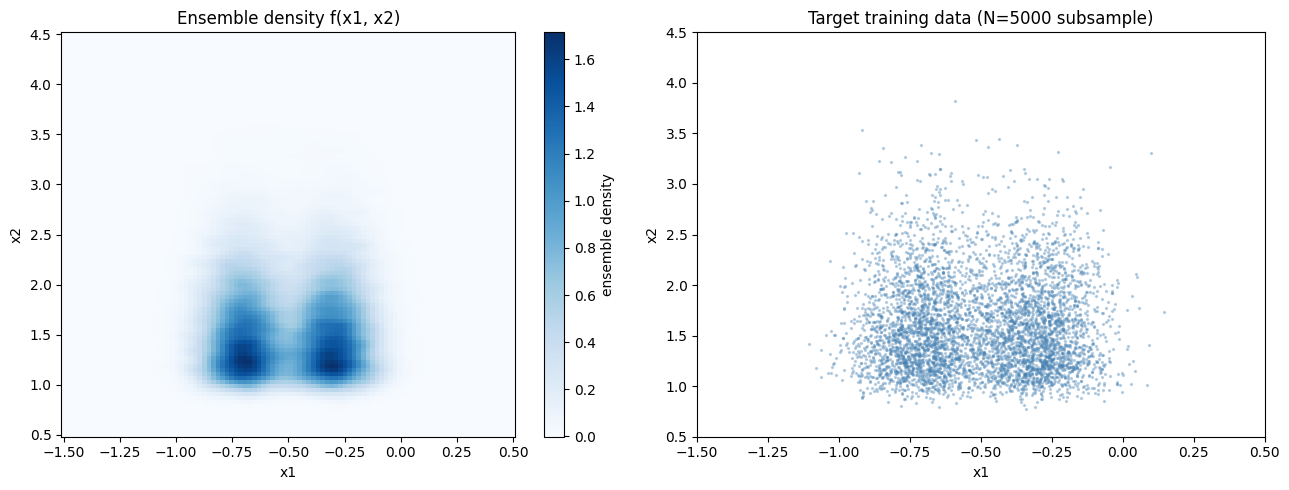

In [3]:
def ensemble_pdf(x, centroids, coefficients, widths, weights):
    """Vectorized evaluation of the weighted Gaussian-kernel ensemble density.
    x : (M, d)
    Returns density values (M,)
    """
    out = np.zeros(x.shape[0])
    for i in range(centroids.shape[0]):
        diff  = x[:, None, :] - centroids[i]                          # (M, K, d)
        z     = np.sum((diff / widths[i])**2, axis=-1)                # (M, K)
        d     = centroids.shape[-1]
        norm  = (2 * np.pi)**(-d / 2) * np.prod(1.0 / widths[i], axis=-1)  # (K,)
        gauss = norm * np.exp(-0.5 * z)                               # (M, K)
        out  += weights[i] * (gauss * coefficients[i]).sum(axis=-1)   # (M,)
    return out

# 2D grid (100x100)
n_grid = 100
x1_grid = np.linspace(*BOUNDS[0], n_grid)
x2_grid = np.linspace(*BOUNDS[1], n_grid)
X1, X2  = np.meshgrid(x1_grid, x2_grid, indexing='ij')
grid_pts = np.c_[X1.ravel(), X2.ravel()]   # (n_grid^2, 2)

pdf_grid = ensemble_pdf(grid_pts, centroids, coefficients, widths, weights)
PDF = pdf_grid.reshape(n_grid, n_grid)

dx1 = x1_grid[1] - x1_grid[0]
dx2 = x2_grid[1] - x2_grid[0]
integral = PDF.sum() * dx1 * dx2
print("Ensemble density integral over bounds: %.4f  (should be close to 1.0)" % integral)

# 2D heatmap vs truth scatter
rng = np.random.default_rng(42)
truth_sub = truth[rng.choice(len(truth), size=5000, replace=False)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].pcolormesh(x1_grid, x2_grid, PDF.T, cmap='Blues', shading='auto')
plt.colorbar(im, ax=axes[0], label='ensemble density')
axes[0].set_title("Ensemble density f(x1, x2)")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2")

axes[1].scatter(truth_sub[:, 0], truth_sub[:, 1], s=2, alpha=0.3, color='steelblue')
axes[1].set_title("Target training data (N=5000 subsample)")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
axes[1].set_xlim(*BOUNDS[0]); axes[1].set_ylim(*BOUNDS[1])

plt.tight_layout()
plt.show()

## 2. Single seed: shape, range, scatter

Shape: (5000, 2)
x1 range: [-1.113, 0.235]
x2 range: [0.782, 3.518]


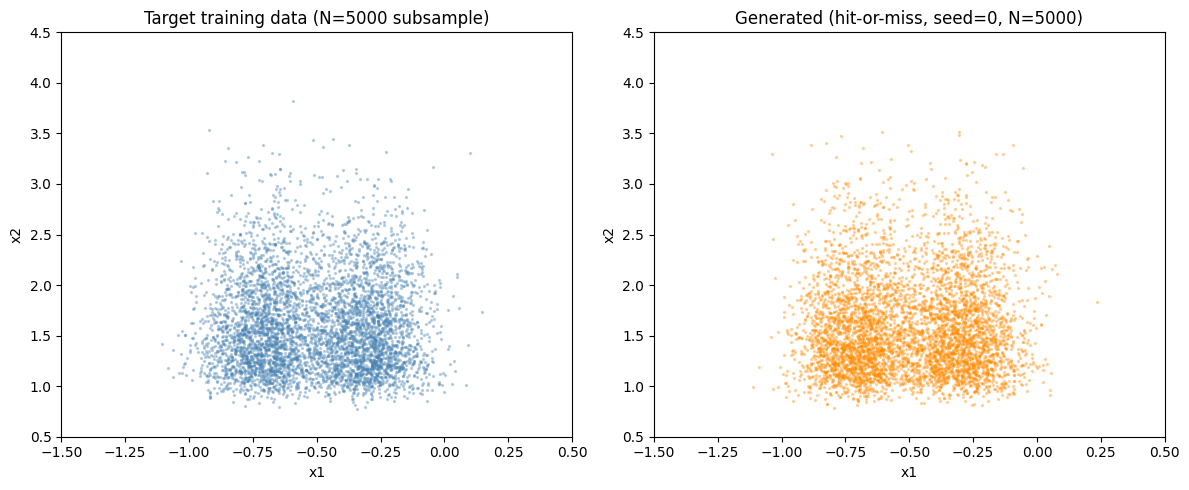

In [4]:
seed = 0
samples = np.load(os.path.join(OUT_DIR, 'seed%i.npy' % seed))
print("Shape:",   samples.shape)          # expect (5000, 2)
print("x1 range: [%.3f, %.3f]" % (samples[:, 0].min(), samples[:, 0].max()))
print("x2 range: [%.3f, %.3f]" % (samples[:, 1].min(), samples[:, 1].max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(truth_sub[:, 0], truth_sub[:, 1], s=2, alpha=0.3, color='steelblue')
axes[0].set_title("Target training data (N=5000 subsample)")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2")
axes[0].set_xlim(*BOUNDS[0]); axes[0].set_ylim(*BOUNDS[1])

axes[1].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.3, color='darkorange')
axes[1].set_title("Generated (hit-or-miss, seed=%i, N=%i)" % (seed, len(samples)))
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
axes[1].set_xlim(*BOUNDS[0]); axes[1].set_ylim(*BOUNDS[1])

plt.tight_layout()
plt.show()

## 3. 1D marginals: target data, ensemble density, generated samples

The ensemble analytic marginals are obtained by integrating the 2D density
over the complementary axis.

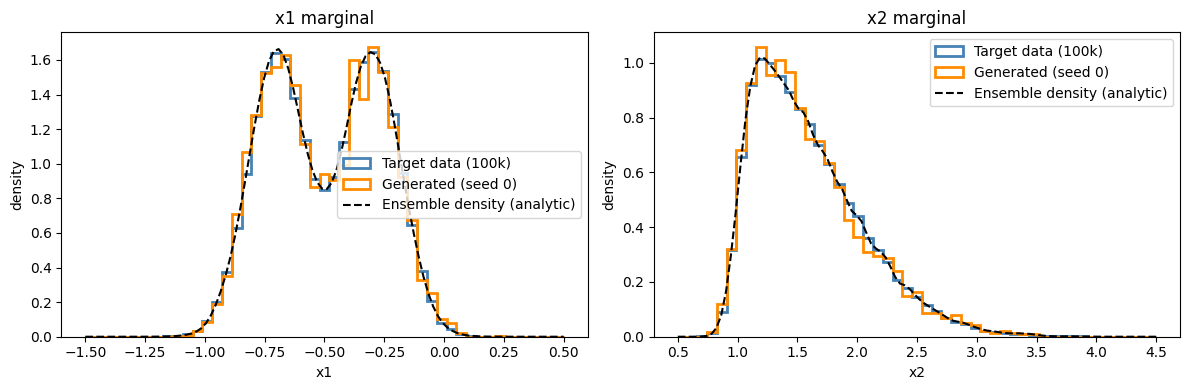

In [5]:
# Marginals from the 2D density grid
marginal_x1 = PDF.sum(axis=1) * dx2   # integrate over x2 -> p(x1)
marginal_x2 = PDF.sum(axis=0) * dx1   # integrate over x1 -> p(x2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# x1 marginal
axes[0].hist(truth[:, 0], bins=bins_x1, density=True,
             histtype='step', color='steelblue', linewidth=2, label='Target data (100k)')
axes[0].hist(samples[:, 0], bins=bins_x1, density=True,
             histtype='step', color='darkorange', linewidth=2, label='Generated (seed %i)' % seed)
axes[0].plot(x1_grid, marginal_x1, 'k--', linewidth=1.5, label='Ensemble density (analytic)')
axes[0].set_xlabel("x1"); axes[0].set_ylabel("density")
axes[0].set_title("x1 marginal")
axes[0].legend()

# x2 marginal
axes[1].hist(truth[:, 1], bins=bins_x2, density=True,
             histtype='step', color='steelblue', linewidth=2, label='Target data (100k)')
axes[1].hist(samples[:, 1], bins=bins_x2, density=True,
             histtype='step', color='darkorange', linewidth=2, label='Generated (seed %i)' % seed)
axes[1].plot(x2_grid, marginal_x2, 'k--', linewidth=1.5, label='Ensemble density (analytic)')
axes[1].set_xlabel("x2"); axes[1].set_ylabel("density")
axes[1].set_title("x2 marginal")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. KS test: generated samples vs target data

In [6]:
ks_x1 = ks_2samp(samples[:, 0], truth[:, 0])
ks_x2 = ks_2samp(samples[:, 1], truth[:, 1])

print("KS test (generated seed %i vs target data)" % seed)
print("  x1:  statistic=%.4f  p-value=%.4f" % (ks_x1.statistic, ks_x1.pvalue))
print("  x2:  statistic=%.4f  p-value=%.4f" % (ks_x2.statistic, ks_x2.pvalue))
print()
print("A large p-value (>> 0.05) means we cannot reject the hypothesis")
print("that the two samples are drawn from the same distribution.")

KS test (generated seed 0 vs target data)
  x1:  statistic=0.0103  p-value=0.6904
  x2:  statistic=0.0186  p-value=0.0730

A large p-value (>> 0.05) means we cannot reject the hypothesis
that the two samples are drawn from the same distribution.


## 5. Consistency check across all seed files

In [7]:
seed_files = sorted([f for f in os.listdir(OUT_DIR) if f.endswith('.npy')])
print("Files found: %i" % len(seed_files))

n_events = []
for f in seed_files:
    arr = np.load(os.path.join(OUT_DIR, f))
    n_events.append(arr.shape[0])

n_events = np.array(n_events)
print("Events per file: min=%i  max=%i  mean=%.1f" % (n_events.min(), n_events.max(), n_events.mean()))
print("Total events: %i" % n_events.sum())

wrong = [(f, n) for f, n in zip(seed_files, n_events) if n != 5000]
if wrong:
    print("WARNING: files with unexpected event count:")
    for f, n in wrong:
        print("  %s: %i" % (f, n))
else:
    print("All files have exactly 5000 events. ✓")

Files found: 200
Events per file: min=5000  max=5000  mean=5000.0
Total events: 1000000
All files have exactly 5000 events. ✓


## 6. Overlay of all seeds vs target (x1 and x2 marginals)

The orange histograms should closely track the blue target curve across all 200 seeds.

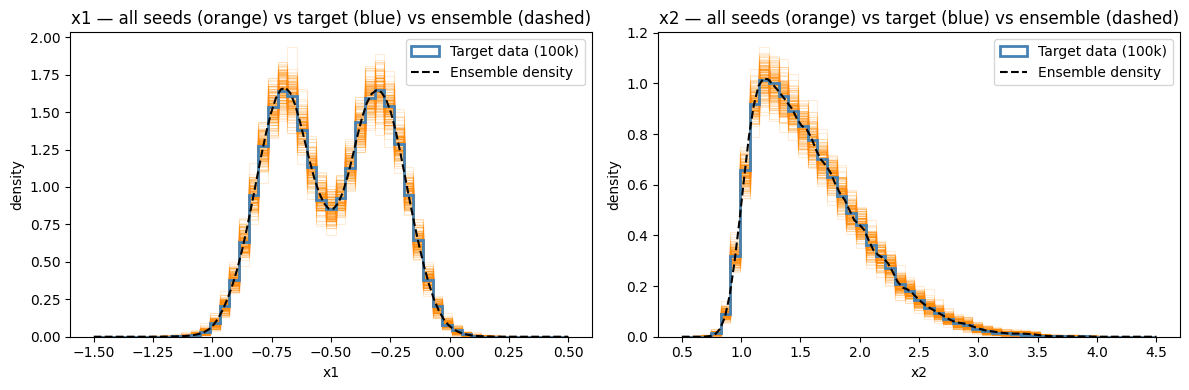

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for f in seed_files:
    arr = np.load(os.path.join(OUT_DIR, f))
    axes[0].hist(arr[:, 0], bins=bins_x1, density=True,
                 histtype='step', color='darkorange', alpha=0.15, linewidth=0.8)
    axes[1].hist(arr[:, 1], bins=bins_x2, density=True,
                 histtype='step', color='darkorange', alpha=0.15, linewidth=0.8)

axes[0].hist(truth[:, 0], bins=bins_x1, density=True,
             histtype='step', color='steelblue', linewidth=2, label='Target data (100k)')
axes[0].plot(x1_grid, marginal_x1, 'k--', linewidth=1.5, label='Ensemble density')

axes[1].hist(truth[:, 1], bins=bins_x2, density=True,
             histtype='step', color='steelblue', linewidth=2, label='Target data (100k)')
axes[1].plot(x2_grid, marginal_x2, 'k--', linewidth=1.5, label='Ensemble density')

axes[0].set_xlabel("x1"); axes[0].set_title("x1 — all seeds (orange) vs target (blue) vs ensemble (dashed)")
axes[1].set_xlabel("x2"); axes[1].set_title("x2 — all seeds (orange) vs target (blue) vs ensemble (dashed)")
for ax in axes:
    ax.set_ylabel("density")
    ax.legend()

plt.tight_layout()
plt.show()